In [251]:
import numpy             as np
import scipy.signal      as signal
import matplotlib.pyplot as plt
import soundfile         as sf
import librosa           

In [252]:
# Carregar o áudio (substitua 'audio.wav' pelo seu arquivo)
y, sr = librosa.load('sinal_musical_com_ruido_rosa.wav', sr=44100)  # Carrega a 44.1 kHz

# Reduzir a taxa de amostragem para 16 kHz
y_resampled = librosa.resample(y, orig_sr=sr, target_sr=16000)

# Salvar o áudio redimensionado (opcional)
sf.write('audio_16kHz.wav', y_resampled, 16000)

# Carregar sinal de áudio
audio, fs = sf.read('audio_16kHz.wav')  # use um WAV mono de 8kHz ou 16kHz

In [253]:
# Parâmetros do filtro
fc = 430  # frequência de corte (Hz)
norm_fc = fc / (fs / 2)  # normalizada

In [254]:
# FIR - janela de Hamming
fir_order = 101
fir_coeff = signal.firwin(fir_order + 1, norm_fc, window='hamming', pass_zero='lowpass')

In [255]:
# IIR - Butterworth 4ª ordem
iir_order = 10
b_iir, a_iir = signal.butter(iir_order, norm_fc,btype='lowpass')

In [256]:
# Aplicação dos filtros
audio_fir = signal.lfilter(fir_coeff, 1.0, audio)
audio_iir = signal.lfilter(b_iir, a_iir, audio)

# Salvar arquivos filtrados
sf.write("audio_fir_filtrado_rosa.wav", audio_fir, fs)
sf.write("audio_iir_filtrado_rosa.wav", audio_iir, fs)

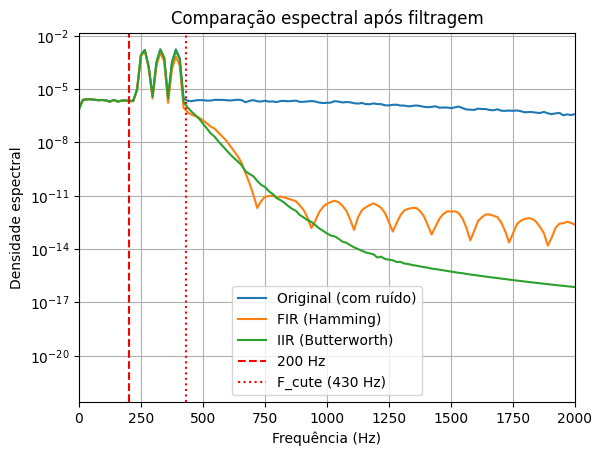

In [257]:
# Espectros
f, Pxx_audio = signal.welch(audio, fs, nperseg=1024)
f, Pxx_fir = signal.welch(audio_fir, fs, nperseg=1024)
f, Pxx_iir = signal.welch(audio_iir, fs, nperseg=1024)


# --- Plotagem dos espectros ---
plt.semilogy(f, Pxx_audio, label='Original (com ruído)')
plt.semilogy(f, Pxx_fir, label='FIR (Hamming)')
plt.semilogy(f, Pxx_iir, label='IIR (Butterworth)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Densidade espectral')
plt.axvline(x=200, color='r', linestyle='--', label='200 Hz')  # Linha para a fundamental
plt.axvline(x=430, color='r', linestyle=':', label='F_cute (430 Hz)')
plt.legend()
plt.title('Comparação espectral após filtragem')
plt.grid()
plt.xlim(0, 2000)  # Foco nas frequências baixas
plt.show()


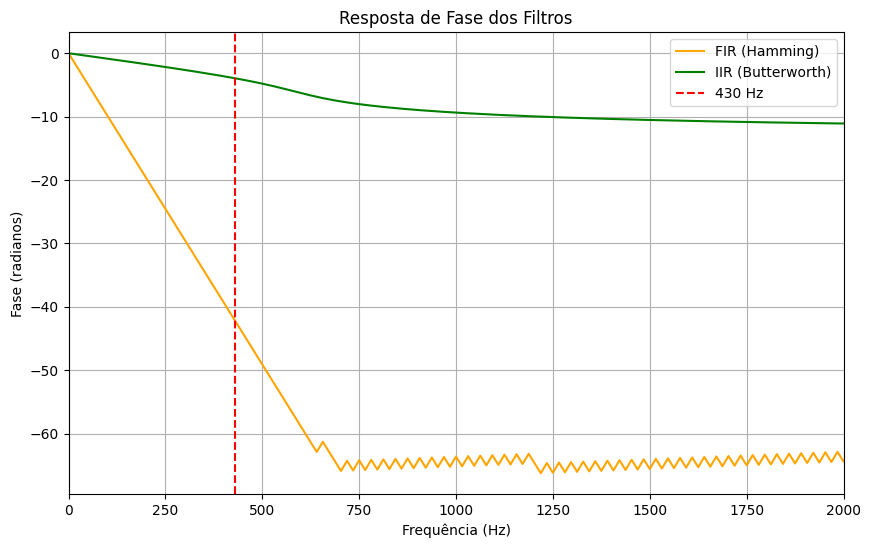

In [258]:
# FIR
fir_coeff = signal.firwin(501, 600/(16000/2), window='hamming')
w_fir, h_fir = signal.freqz(fir_coeff, fs=16000)
phase_fir = np.unwrap(np.angle(h_fir))

# IIR
b_iir, a_iir = signal.butter(8, 600/(16000/2), btype='lowpass')
w_iir, h_iir = signal.freqz(b_iir, a_iir, fs=16000)
phase_iir = np.unwrap(np.angle(h_iir))

# --- Plotagem ---
plt.figure(figsize=(10, 6))
plt.plot(w_fir, phase_fir, label='FIR (Hamming)', color='orange')
plt.plot(w_iir, phase_iir, label='IIR (Butterworth)', color='green')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Fase (radianos)')
plt.axvline(x=430, color='red', linestyle='--', label='430 Hz')
plt.legend()
plt.grid()
plt.xlim(0, 2000)  # Foco até 2000 Hz
plt.title('Resposta de Fase dos Filtros')
plt.show()

<p style="text-align: justing;">Um filtro tem fase linear na banda de passagem quando o atraso de fase introduzido pelo filtro varia linearmente com a frequência, ou seja, quando a derivada primeira da fase em função da frequência resulta em uma constante. Matematicamente, isso significa que a fase obedece a:</p>

$${\phi(\omega) = -D \cdot \omega + C}~~~~~~~~~~~~~~~~~~~~~~~~~~~(1)$$

onde:

- $D$ é o atraso de grupo constante(em segundos),
- $C$ é uma constante(geralmente 0 ou multiplo de $\pi$),
- $\omega$ é a frequência angular. 

<div style="text-align: justing;">

**IMPLICAÇÕES PRÁTICAS**  
• Preservação da forma de onda, ou seja, sinais na banda de passagem **não sofrem distorção de fase**, ou ainda: componentes de frequêcia diferentes são atrasados pelo mesmo tempo.

• Para que a derivada em $(1)$ seja constante, ou melhor, o **Atraso de grupo constante** os filtros devem apresentar resposta de fase linear, que nesse caso apenas o filtro FIR atende ao este requisito.

• A distorção de fase, ou ainda, a não-linearidade no atraso das diferentes componentes de frequência gera "sujeiras(*smearing*)" nos transientes dos sinais.

• Em contra partida, a não linearidade dos filtros IIR na música é útil para o "Tempero Artístico": pode-se reforçar(+gain) ou atenuar(-gain) em uma determinada frequência, a não linearidade também é ideal para projetos de sintetizadores digitais e efeitos sonoros mais diversos, onde "bagunçar" a fase dos frequência é o objetivo.

• Filtros IIR, também são últeis para sistemas embarcados, devido ao seu significativo número reduzido de coeficiêntes.

</div>



# Comparação IIR vs FIR

| Característica               | IIR                            | FIR                            |
|------------------------------|--------------------------------|--------------------------------|
| **Número de coeficientes**    | ✅ Menos para mesma atenuação  | ❌ Precisa de mais coeficientes |
| **Fase**                     | ❌ Não linear (distorção temporal) | ✅ Linear (preserva forma de onda) |
| **Atraso de processamento**  | ✅ Baixo                       | ❌ Alto (depende da ordem)     |
| **Estabilidade numérica**    | ❌ Risco de instabilidade      | ✅ Inerentemente estável       |
| **Eficiência em hardware**   | ✅ Alta (DSP/FPGA)             | ❌ Consome mais recursos       |
| **Projeto de fase linear**   | ❌ Difícil                     | ✅ Fácil                       |



<div style="text-align: center; font-family: Arial, sans-serif;">
  <h1 style="color: #2e6c80; margin-bottom: 20px;">Comparação IIR vs FIR</h1>
  
  <table style="margin: 0 auto; border-collapse: collapse; box-shadow: 0 2px 5px rgba(0,0,0,0.1);">
    <thead>
      <tr style="background-color: #2e6c80; color: white;">
        <th style="padding: 12px 15px; border: 1px solid #ddd; min-width: 200px;">Característica</th>
        <th style="padding: 12px 15px; border: 1px solid #ddd; min-width: 150px;">IIR</th>
        <th style="padding: 12px 15px; border: 1px solid #ddd; min-width: 150px;">FIR</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding: 10px 15px; border: 1px solid #ddd; font-weight: bold;">Número de coeficientes</td>
        <td style="padding: 10px 15px; border: 1px solid #ddd; text-align: center;">✅ Menos para mesma atenuação</td>
        <td style="padding: 10px 15px; border: 1px solid #ddd; text-align: center;">❌ Precisa de mais coeficientes</td>
      </tr>
      <tr style="background-color:rgb(0, 0, 0);">
        <td style="padding: 10px 15px; border: 1px solid #ddd; font-weight: bold;">Fase</td>
        <td style="padding: 10px 15px; border: 1px solid #ddd; text-align: center;">❌ Não linear (distorção temporal)</td>
        <td style="padding: 10px 15px; border: 1px solid #ddd; text-align: center;">✅ Linear (preserva forma de onda)</td>
      </tr>
      <tr>
        <td style="padding: 10px 15px; border: 1px solid #ddd; font-weight: bold;">Atraso de processamento</td>
        <td style="padding: 10px 15px; border: 1px solid #ddd; text-align: center;">✅ Baixo</td>
        <td style="padding: 10px 15px; border: 1px solid #ddd; text-align: center;">❌ Alto (depende da ordem)</td>
      </tr>
      <tr style="background-color:rgb(0, 0, 0);">
        <td style="padding: 10px 15px; border: 1px solid #ddd; font-weight: bold;">Estabilidade numérica</td>
        <td style="padding: 10px 15px; border: 1px solid #ddd; text-align: center;">❌ Risco de instabilidade</td>
        <td style="padding: 10px 15px; border: 1px solid #ddd; text-align: center;">✅ Inerentemente estável</td>
      </tr>
      <tr>
        <td style="padding: 10px 15px; border: 1px solid #ddd; font-weight: bold;">Eficiência em hardware</td>
        <td style="padding: 10px 15px; border: 1px solid #ddd; text-align: center;">✅ Alta (DSP/FPGA)</td>
        <td style="padding: 10px 15px; border: 1px solid #ddd; text-align: center;">❌ Consome mais recursos</td>
      </tr>
      <tr style="background-color:rgb(0, 0, 0);">
        <td style="padding: 10px 15px; border: 1px solid #ddd; font-weight: bold;">Projeto de fase linear</td>
        <td style="padding: 10px 15px; border: 1px solid #ddd; text-align: center;">❌ Difícil</td>
        <td style="padding: 10px 15px; border: 1px solid #ddd; text-align: center;">✅ Fácil</td>
      </tr>
    </tbody>
  </table>
  
  <!-- <div style="margin-top: 20px; font-size: 0.9em; color: #666;">
    <strong>Legenda:</strong> ✅ Vantagem | ❌ Desvantagem -->
  </div>
</div>